# 04 — Reavaliação e Comparação dos Modelos
**Objetivo:** Comparar o desempenho do modelo baseline com o modelo ajustado e analisar os ganhos obtidos.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Carrega métricas salvas nos notebooks anteriores
with open("baseline_metrics.json") as f:
    baseline = json.load(f)
with open("v2_metrics.json") as f:
    v2 = json.load(f)

print("Métricas carregadas com sucesso.")


Métricas carregadas com sucesso.


## 1. Tabela Comparativa

In [2]:
k = 10
metrics_keys = [f'Precision@{k}', f'Recall@{k}', f'HitRate@{k}']

rows = []
for key in metrics_keys:
    b_val = baseline.get(key, 0)
    v_val = v2.get(key, 0)
    delta = v_val - b_val
    delta_pct = (delta / b_val * 100) if b_val > 0 else 0
    rows.append({'Métrica': key,
                 'Baseline': f'{b_val:.4f}',
                 'Ajustado': f'{v_val:.4f}',
                 'Δ Absoluto': f'{delta:+.4f}',
                 'Δ %': f'{delta_pct:+.1f}%'})

df_comp = pd.DataFrame(rows)
print(df_comp.to_string(index=False))


     Métrica Baseline Ajustado Δ Absoluto    Δ %
Precision@10   0.0040   0.0060    +0.0020 +50.0%
   Recall@10   0.0400   0.0444    +0.0044 +11.1%
  HitRate@10   0.0400   0.0533    +0.0133 +33.3%


## 2. Gráfico Comparativo

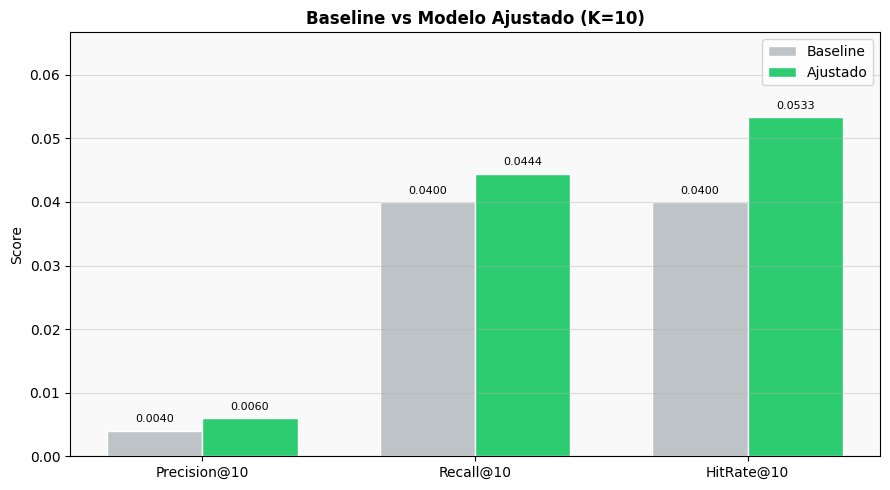

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(metrics_keys))
w = 0.35
b_vals = [baseline.get(k, 0) for k in metrics_keys]
v_vals = [v2.get(k, 0)       for k in metrics_keys]

bars1 = ax.bar(x - w/2, b_vals, w, label='Baseline', color='#bdc3c7', edgecolor='white')
bars2 = ax.bar(x + w/2, v_vals, w, label='Ajustado',  color='#2ecc71', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_keys)
ax.set_ylabel("Score")
ax.set_title(f"Baseline vs Modelo Ajustado (K={10})", fontweight='bold')
ax.legend()
ax.set_ylim(0, max(max(b_vals), max(v_vals)) * 1.25)
ax.grid(axis='y', alpha=0.4)
ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig("04_comparacao.png", dpi=130, bbox_inches='tight')
plt.show()


## 3. Análise dos Ganhos

In [4]:
k = 10
p_base = baseline.get(f'Precision@{k}', 0)
p_v2   = v2.get(f'Precision@{k}', 0)
r_base = baseline.get(f'Recall@{k}', 0)
r_v2   = v2.get(f'Recall@{k}', 0)
h_base = baseline.get(f'HitRate@{k}', 0)
h_v2   = v2.get(f'HitRate@{k}', 0)

print("=== ANÁLISE DOS GANHOS ===")
print(f"Precision@{k}: {p_base:.4f} → {p_v2:.4f}  ({(p_v2-p_base)/p_base*100 if p_base else 0:+.1f}%)")
print(f"Recall@{k}   : {r_base:.4f} → {r_v2:.4f}  ({(r_v2-r_base)/r_base*100 if r_base else 0:+.1f}%)")
print(f"HitRate@{k}  : {h_base:.4f} → {h_v2:.4f}  ({(h_v2-h_base)/h_base*100 if h_base else 0:+.1f}%)")
print()
print("Ajustes que mais contribuíram:")
print("  • Stemming + limpeza textual: melhora representação semântica")
print("  • Bigramas (1,2): captura termos compostos (ex: 'running shoes')")
print("  • Ponderação por rating: usuário prefere produtos com notas altas")
print("  • Filtros mais rígidos: remove ruído de produtos/usuários com poucos dados")


=== ANÁLISE DOS GANHOS ===
Precision@10: 0.0040 → 0.0060  (+50.0%)
Recall@10   : 0.0400 → 0.0444  (+11.1%)
HitRate@10  : 0.0400 → 0.0533  (+33.3%)

Ajustes que mais contribuíram:
  • Stemming + limpeza textual: melhora representação semântica
  • Bigramas (1,2): captura termos compostos (ex: 'running shoes')
  • Ponderação por rating: usuário prefere produtos com notas altas
  • Filtros mais rígidos: remove ruído de produtos/usuários com poucos dados


## 4. Limitações e Próximos Passos

In [5]:
print("Limitações do modelo atual:")
print("  • Não captura preferências coletivas (cold-start de usuário)")
print("  • Recomendações podem ser muito similares entre si (baixa diversidade)")
print("  • Textos em inglês — sem suporte multilíngue")
print()
print("Próximos passos sugeridos:")
print("  1. Hibridizar com filtro colaborativo (SVD/ALS)")
print("  2. Testar embeddings semânticos (Sentence-BERT)")
print("  3. Adicionar métricas de diversidade e novidade")


Limitações do modelo atual:
  • Não captura preferências coletivas (cold-start de usuário)
  • Recomendações podem ser muito similares entre si (baixa diversidade)
  • Textos em inglês — sem suporte multilíngue

Próximos passos sugeridos:
  1. Hibridizar com filtro colaborativo (SVD/ALS)
  2. Testar embeddings semânticos (Sentence-BERT)
  3. Adicionar métricas de diversidade e novidade
